In [ ]:
# Create shifted interest rates and exchange rates to represent t-1
combined_df['US_10Y_IR_daily_t-1'] = combined_df['US_10Y_IR_daily'].shift(1)
combined_df['Japan_10Y_IR_daily_t-1'] = combined_df['Japan_10Y_IR_daily'].shift(1)
combined_df['Exchange_Rate_t-1'] = combined_df['JPY_USD_Exchange_Rate'].shift(1)

# Carry trade returns
combined_df['carry_trade_returns'] = ((1 + combined_df['US_10Y_IR_daily_t-1']) *
                                      (combined_df['JPY_USD_Exchange_Rate'] / combined_df['Exchange_Rate_t-1'])) - (1 + combined_df['Japan_10Y_IR_daily_t-1'])

# Drop rows with NaN values caused by shifting
combined_df.dropna(inplace=True)

In [ ]:
combined_df.describe()

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(combined_df.index, combined_df['carry_trade_returns']*100, label='Daily Carry Trade Returns', alpha=0.8)
plt.title("Daily Carry Trade Returns (2000-01-04 to 2024-11-15)")
plt.xlabel("Date")
plt.ylabel("Return %");

In [ ]:
# Save the return dataset
combined_df['carry_trade_returns'].to_csv("/Users/alexzheng/Developer/GitHub/Forecasting-Yen-Carry-Trade-Risk-Using-an-LLM/data/returns.csv", index=True)

### Compute VaR and ES

In [ ]:
# !pip install scipy

In [ ]:
returns = combined_df['carry_trade_returns']

Skewness: -0.31118385346823
Kurtosis: 4.1755067297716995


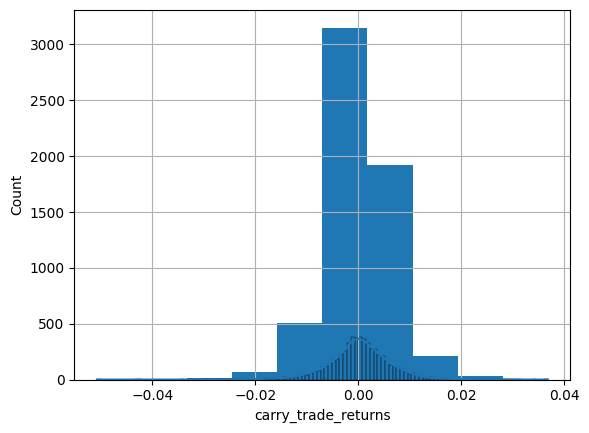

In [ ]:
returns.hist()
import seaborn as sns
sns.histplot(returns, kde=True)

skewness = returns.skew()
kurtosis = returns.kurt()
print("Skewness:", skewness)
print("Kurtosis:", kurtosis)

#### Find the best distribution for the returns

In [ ]:
# !pip install fitter

2025-01-20 13:06:08.597 | INFO     | fitter.fitter:_fit_single_distribution:333 - Fitted norm distribution with error=3292.335358)
2025-01-20 13:06:08.610 | INFO     | fitter.fitter:_fit_single_distribution:333 - Fitted expon distribution with error=54910.337419)
2025-01-20 13:06:08.621 | INFO     | fitter.fitter:_fit_single_distribution:333 - Fitted laplace distribution with error=586.847626)
2025-01-20 13:06:08.656 | INFO     | fitter.fitter:_fit_single_distribution:333 - Fitted skewnorm distribution with error=3125.384233)
2025-01-20 13:06:08.679 | INFO     | fitter.fitter:_fit_single_distribution:333 - Fitted gamma distribution with error=63022.531601)
2025-01-20 13:06:08.684 | INFO     | fitter.fitter:_fit_single_distribution:333 - Fitted t distribution with error=391.223947)
2025-01-20 13:06:08.715 | INFO     | fitter.fitter:_fit_single_distribution:333 - Fitted lognorm distribution with error=3291.077016)
2025-01-20 13:06:08.722 | INFO     | fitter.fitter:_fit_single_distributio

          sumsquare_error         aic         bic  kl_div  ks_statistic  \
t              391.223947    3.533433   23.590188     inf      0.013621   
laplace        586.847626   48.671588   62.042758     inf      0.017730   
skewnorm      3125.384233  722.746838  742.803593     inf      0.051507   
lognorm       3291.077016  892.115322  912.172077     inf      0.058132   
norm          3292.335358  869.272810  882.643980     inf      0.058467   

             ks_pvalue  
t         2.203098e-01  
laplace   4.788465e-02  
skewnorm  4.404555e-14  
lognorm   8.017600e-18  
norm      5.042163e-18  


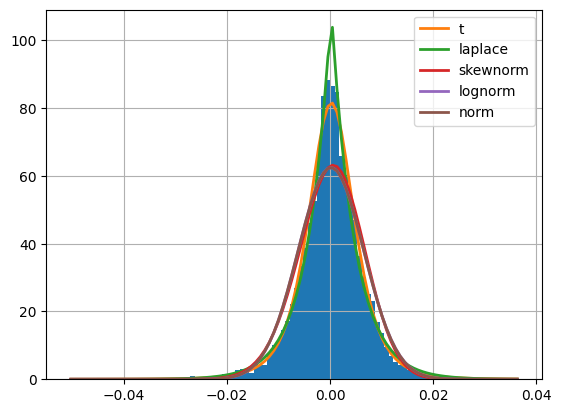

In [ ]:
from fitter import Fitter

# Extract the return series

# Fit multiple distributions
f = Fitter(returns, distributions=['norm', 't', 'skewnorm', 'laplace', 'expon', 'gamma', 'lognorm', 'genextreme'])
f.fit()

# Get the best-fitting distribution
print(f.summary())

In [ ]:
import numpy as np
import scipy.stats as stats
from scipy.stats import t

# Fit Student's t-distribution to the actual returns data
df_t, loc, scale = t.fit(returns)

# Monte Carlo Simulation using t-distribution
num_simulations = 100000 
simulated_returns = t.rvs(df_t, loc=loc, scale=scale, size=num_simulations)

# Calculate Value at Risk (VaR)
confidence_level = 0.95  # 95% Confidence
var_threshold = 1 - confidence_level
VaR = np.percentile(simulated_returns, var_threshold * 100)  # 5th percentile

# Calculate Expected Shortfall (ES) (Conditional VaR)
ES = np.mean(simulated_returns[simulated_returns <= VaR])

# Display Results
print(f"Student's t-Distribution Parameters: df={df_t:.4f}, loc={loc:.6f}, scale={scale:.6f}")
print(f"Value at Risk (VaR) at {confidence_level * 100}% confidence: {VaR:.4f}")
print(f"Expected Shortfall (ES): {ES:.4f}")

Student's t-Distribution Parameters: df=3.9480, loc=0.000278, scale=0.004593
Value at Risk (VaR) at 95.0% confidence: -0.0096
Expected Shortfall (ES): -0.0145


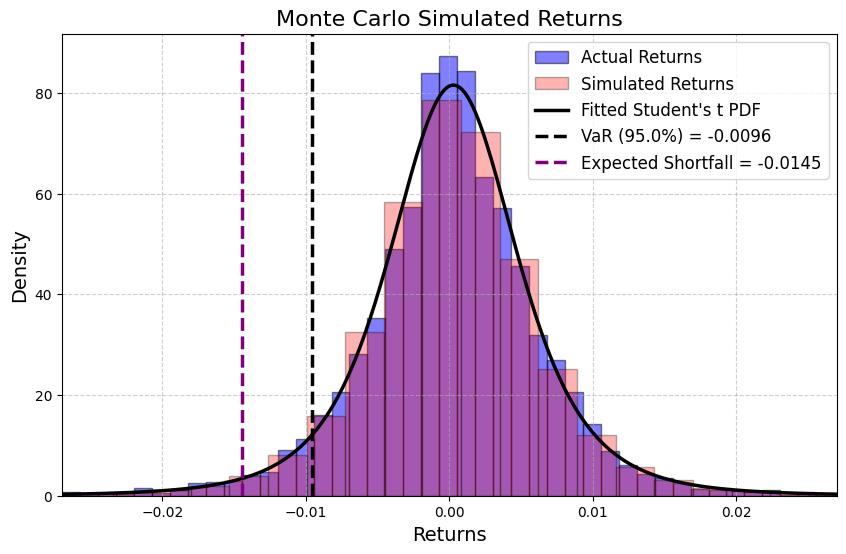

In [ ]:
# Plot settings
plt.figure(figsize=(10, 6))

# Histogram of actual returns
plt.hist(returns, bins=70, density=True, alpha=0.5, color='blue', label="Actual Returns", edgecolor='black')

# Histogram of simulated returns
plt.hist(simulated_returns, bins=70, density=True, alpha=0.3, color='red', label="Simulated Returns", edgecolor='black')

# Overlay Student's t PDF
x_vals = np.linspace(min(simulated_returns), max(simulated_returns), 1000)
pdf_vals = t.pdf(x_vals, df_t, loc=loc, scale=scale)
plt.plot(x_vals, pdf_vals, 'k', linewidth=2.5, label="Fitted Student's t PDF")

# Mark VaR and ES
plt.axvline(VaR, color='black', linestyle="dashed", linewidth=2.5, label=f"VaR ({confidence_level*100}%) = {VaR:.4f}")
plt.axvline(ES, color='purple', linestyle="dashed", linewidth=2.5, label=f"Expected Shortfall = {ES:.4f}")

# Limit x-axis between -0.027 and 0.027
plt.xlim(-0.027, 0.027)

# Labels and title
plt.xlabel("Returns", fontsize=14)
plt.ylabel("Density", fontsize=14)
plt.title("Monte Carlo Simulated Returns", fontsize=16)

# Grid, legend, and formatting
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.show()